# Segmentación con U-Net y encoder preentrenado

En este notebook veremos una aplicación distinta de los modelos visuales: la **segmentación de imágenes**.

A diferencia de la clasificación, donde el modelo entrega una sola etiqueta por imagen, en segmentación el objetivo es predecir una clase para cada píxel.

Usaremos una arquitectura tipo **U-Net** con un **encoder preentrenado**.

## Objetivos de este notebook

Al finalizar este notebook deberías poder:

- entender la diferencia entre clasificación y segmentación,
- reconocer la estructura general de una U-Net,
- ver cómo reutilizar un encoder preentrenado,
- y visualizar máscaras predichas sobre imágenes.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Clasificación vs segmentación

### Clasificación
- entrada: una imagen
- salida: una etiqueta

### Segmentación
- entrada: una imagen
- salida: una máscara

En segmentación, el modelo debe decidir qué clase corresponde a cada píxel.

## ¿Qué es una [U-Net](https://arxiv.org/pdf/1505.04597)?

Una U-Net tiene dos partes principales:

- **encoder**: reduce resolución y extrae características
- **decoder**: recupera resolución y produce una máscara

Además, usa **skip connections** entre encoder y decoder, para conservar información espacial.

## ¿Dónde entra el transfer learning?

En este notebook reutilizaremos un **encoder preentrenado**.

La idea es:

- usar una red que ya aprendió representaciones visuales generales,
- tomar algunas de sus capas intermedias,
- y construir encima un decoder para segmentación.

Esto conecta directamente con la idea de **transfer learning** vista en clasificación.

## Dataset

Usaremos el dataset **Oxford-IIIT Pet** con máscaras de segmentación.

Trabajaremos con una versión reducida y pedagógica del pipeline, enfocándonos en:

- cargar datos,
- visualizar imágenes y máscaras,
- construir el modelo,
- y mostrar predicciones.

In [2]:
dataset, info = tfds.load("oxford_iiit_pet", with_info=True)

train_ds = dataset["train"]
test_ds = dataset["test"]

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ZKPIV2_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.ZKPIV2_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
       

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

## Preprocesamiento de imágenes y máscaras

En este problema tenemos dos objetos:

- la imagen de entrada,
- la máscara objetivo.

Debemos redimensionar ambas, pero con cuidado:

- la imagen puede redimensionarse normalmente,
- la máscara debe redimensionarse preservando clases enteras.

In [4]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.int32) - 1
    return input_image, input_mask

def load_image(datapoint):
    image = tf.image.resize(datapoint["image"], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(
        datapoint["segmentation_mask"],
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    )
    image, mask = normalize(image, mask)
    return image, mask

In [5]:
train_images = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_images = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)

In [6]:
train_batches = train_images.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_batches = test_images.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## Visualización de ejemplos

Antes de construir el modelo, conviene visualizar algunas imágenes junto con sus máscaras.

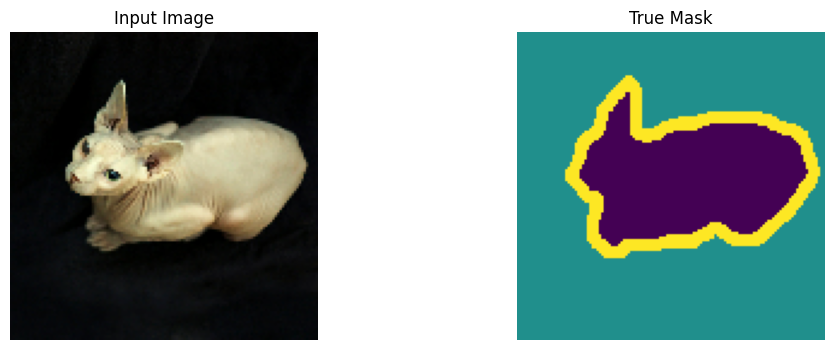

In [7]:
def display_sample(display_list):
    plt.figure(figsize=(12, 4))
    titles = ["Input Image", "True Mask", "Predicted Mask"]

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(titles[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis("off")
    plt.show()

for image, mask in train_images.take(1):
    display_sample([image, mask])

## Encoder preentrenado: MobileNetV2

Usaremos **MobileNetV2** como encoder.

La idea será tomar algunas capas intermedias del modelo y usarlas como bloques de extracción de características a distintas escalas.

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=[IMG_SIZE, IMG_SIZE, 3],
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Capas de skip connection

En U-Net, las skip connections ayudan a recuperar detalle espacial en el decoder.

Por eso seleccionaremos varias capas intermedias del encoder.

In [9]:
layer_names = [
    "block_1_expand_relu",   # 64x64
    "block_3_expand_relu",   # 32x32
    "block_6_expand_relu",   # 16x16
    "block_13_expand_relu",  # 8x8
    "block_16_project",      # 4x4
]

base_model_outputs = [base_model.get_layer(name).output for name in layer_names]
down_stack = keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

## Decoder

Ahora construiremos la parte ascendente del modelo, es decir, el decoder.

La idea es:

- ir [aumentando resolución](https://towardsdatascience.com/transposed-convolutional-neural-networks-how-to-increase-the-resolution-of-your-image-d1ec27700c6a/),
- combinar con información del encoder,
- y finalmente producir una máscara por píxel.

In [10]:
def upsample(filters, size):
    initializer = tf.random_normal_initializer(0.0, 0.02)

    result = keras.Sequential()
    result.add(
        layers.Conv2DTranspose(
            filters, size, strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )
    result.add(layers.BatchNormalization())
    result.add(layers.ReLU())

    return result

In [11]:
up_stack = [
    upsample(512, 3),
    upsample(256, 3),
    upsample(128, 3),
    upsample(64, 3),
]

## Construcción del modelo U-Net

Aquí conectamos:

- encoder preentrenado,
- skip connections,
- decoder,
- capa final de segmentación.

In [12]:
def unet_model(output_channels):
    inputs = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    last = layers.Conv2DTranspose(
        output_channels, 3, strides=2,
        padding="same"
    )

    x = last(x)

    return keras.Model(inputs=inputs, outputs=x)

In [13]:
OUTPUT_CHANNELS = 3
model = unet_model(OUTPUT_CHANNELS)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 8, 8, 512) │  1,476,608 │ functional[0][4]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ sequential[0][0], │
│ (Concatenate)       │ 1088)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 16, 16,    │  2,507,776 │ concatenate[0][0] │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    516,608 │ concatenate_1[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ sequential_2[0][… │
│ (Concatenate)       │ 272)              │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 64,    │    156,928 │ concatenate_2[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 160)              │            │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │      4,323 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,504,227 (24.81 MB)

 Trainable params: 4,660,323 (17.78 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

## Compilación del modelo

Como aquí tenemos segmentación multiclase por píxel, usaremos una pérdida apropiada para clasificación por píxel.

In [14]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

## Predicción sin entrenar

Antes de entrenar, podemos ver cómo luce la salida inicial del modelo.

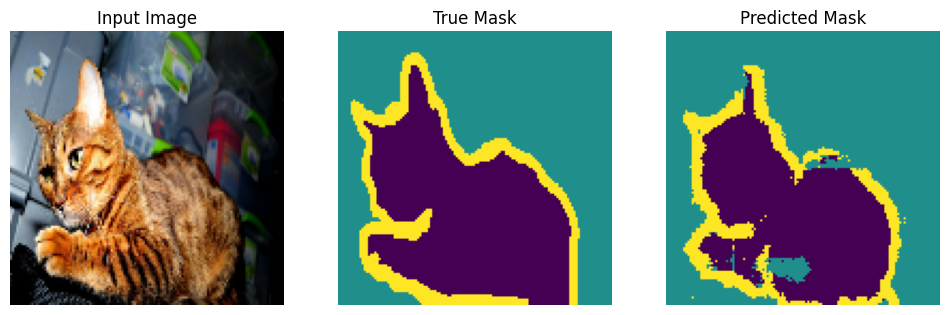

In [26]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

for images, masks in train_batches.take(1):
    sample_image, sample_mask = images[0], masks[0]
    pred_mask = model.predict(sample_image[tf.newaxis, ...], verbose=0)
    display_sample([sample_image, sample_mask, create_mask(pred_mask)])

## Entrenamiento corto

Aquí haremos solo un entrenamiento breve, pensando en una demo de clase.

La idea no es optimizar completamente el modelo, sino mostrar el flujo.

In [16]:
EPOCHS = 3
history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=test_batches
)

Epoch 1/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 69s 366ms/step - accuracy: 0.8380 - loss: 0.4146 - val_accuracy: 0.8838 - val_loss: 0.3144
Epoch 2/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.8922 - loss: 0.2810 - val_accuracy: 0.8951 - val_loss: 0.2751
Epoch 3/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.8988 - loss: 0.2605 - val_accuracy: 0.8875 - val_loss: 0.2950


## Curvas de entrenamiento

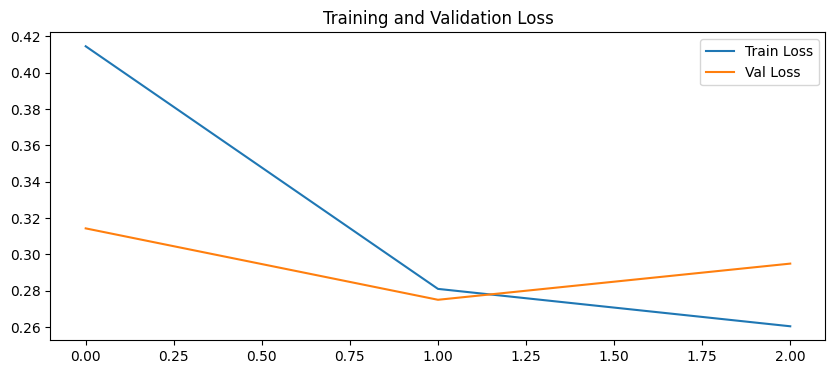

In [27]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

## Visualizar predicciones

Ahora compararemos:

- imagen original,
- máscara verdadera,
- máscara predicha.

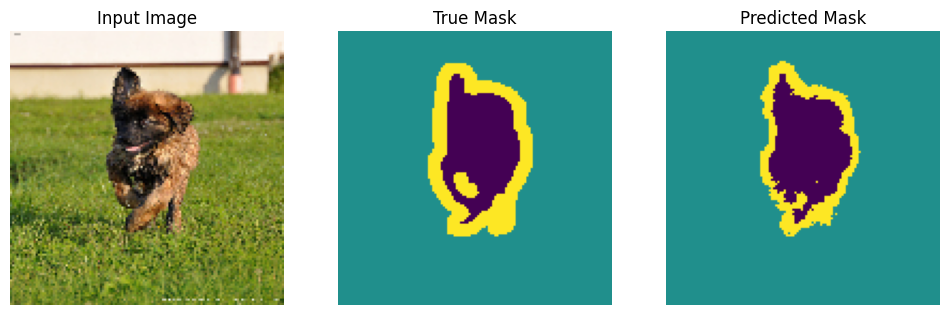

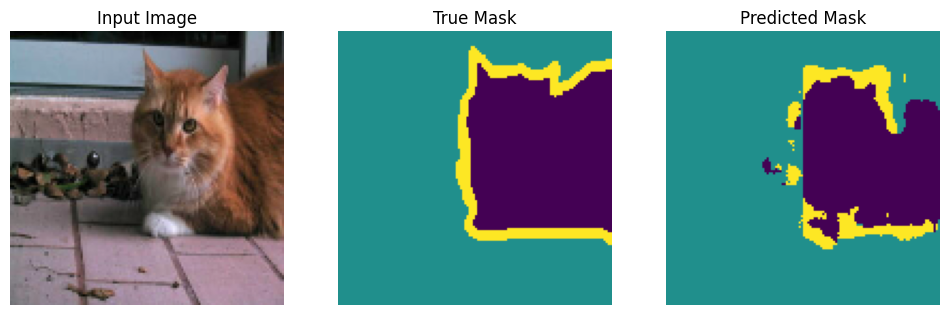

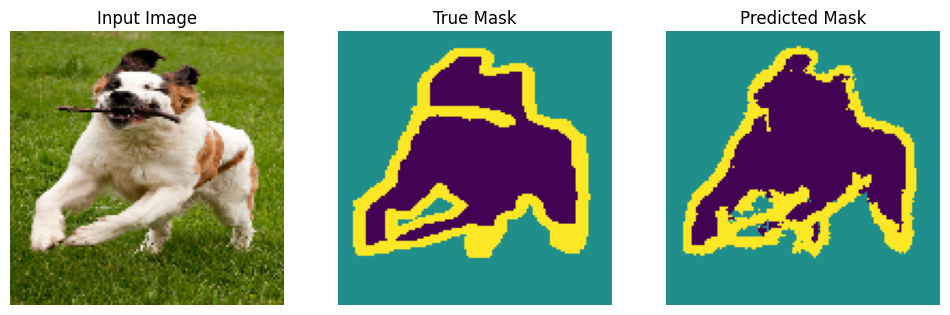

In [28]:
for images, masks in test_batches.take(1):
    pred_masks = model.predict(images[:3], verbose=0)

    for i in range(3):
        display_sample([
            images[i],
            masks[i],
            create_mask(pred_masks[i:i+1])
        ])

## ¿Qué aprendimos aquí?

En este notebook vimos que el transfer learning no solo sirve para clasificación.

También podemos reutilizar un encoder preentrenado como parte de una arquitectura de segmentación.

### Idea central
- el encoder aporta representaciones visuales útiles,
- el decoder reconstruye una salida espacial,
- y las skip connections ayudan a recuperar detalle.

## Conexión con U-Net

Aunque aquí usamos un encoder preentrenado moderno, la lógica general sigue siendo la de U-Net:

- bajar resolución para extraer características,
- subir resolución para producir la máscara,
- combinar información profunda con detalle espacial.

## Bonus: ideas para extender este notebook

1. descongelar parte del encoder y hacer fine-tuning,
2. cambiar MobileNetV2 por ResNet,
3. probar otra tarea de segmentación,
4. comparar con un modelo de segmentación ya preentrenado,
5. usar una arquitectura moderna como DeepLabV3+ o SegFormer.